# Файлы, участвующие в тестировании распознавания маркеров

```
dyslexia-child/
├── demo/
│   └── test_marking.ipynb    # Этот ноутбук
├── model/
│   ├── dysmarkccls_clean.py          # Основной модуль
│   ├── w2vtransf.py                  # Alignment module
│   └── marks.py                      # Error marking module
└── test_data/
    └── markers
        ├── audio/
        │   ├── marker1                   # Каталог с аудио для mark1 (группа замены букв на похожие: Ж-Х)
        │   │    ├── audioXXX.py   
        │   │    └── ...    
        │   ├── marker2                   # Аудио для mark2 (группа замены букв на похожие: Н-П)
        │   ├── marker3                   # Аудио для mark3 (группа замены букв на похожие: Н-И)
        │   ├── marker4                   # Аудио для mark4 (группа замены букв на похожие: В-З)    
        │   ├── marker5                   # Аудио для mark5 (группа замены букв на похожие: Т-Г)
        │   ├── marker6                   # Аудио для mark6 (группа замены букв на похожие: Р-Ь)
        │   ├── marker7                   # Аудио для mark7 (группа замены звука на фонетически похожий: Д-Т)    
        │   ├── marker8                   # Аудио для mark8 (группа замены звука на фонетически похожий: Б-П)    
        │   ├── marker9                   # Аудио для mark9 (группа пропуска: пропуск буквы при стечении "скамейка-камейка")
        │   ├── markerA                   # Аудио для markA (группа пропуска: пропуск буквы при отсутствии стечения "пароход-парход")
        │   ├── markerB                   # Аудио для markB (группа пропуска: пропуск невыговариваемой буквы)
        │   ├── markerC                   # Аудио для markC (группа утрированния букв: утрированная ярко выраженная Р)    
        │   ├── markerD                   # Аудио для markD (группа утрированния букв: повторы произнесения Р-Р-Р)
        │   ├── markerE                   # Аудио для markE (группа произвольной замены неузнанной буквы: Ж_М_Л)
        │   ├── markerF                   # Аудио для markF (группа перестановок: перестановка гласной внутри слова)
        │   ├── markerG                   # Аудио для markG (группа перестановок: перестановка согласной внутри слова "молоко-моколо, лопата-лотапа")    
        │   ├── markerH.wav               # Аудио для markH (группа добавления: добавление дополнительного звука)    
        │   ├── markerI.wav               # Аудио для markI (группа искажения: обмягчение окончания)    
        │   ├── markerJ.wav               # Аудио для markJ (группа общих особенностей: медленный темп чтения относительно возрастной нормы)
        │   └── markerK.wav               # Аудио для markK (группа общих особенностей: чтение по слогам, не объединяемым в слова)
        └── text/
            ├── marker1                   # Каталог с текстами, соответствующими аудио для mark1 (группа замены букв на похожие: Ж-Х)
            │    ├── textXXX.txt          # Текст, соответствующий аудио marker1/audioXXX.wav   
            │    └── ...    
            ...
            └── markerK.txt                   # Каталог с текстами, соответствующими аудио для mark1 (группа замены букв на похожие: Ж-Х)
...
```

# Тестирование Dysmark как библиотеки

Этот ноутбук демонстрирует использование dysmarkсcls_clean.py как модуля для выявления всех типов маркеров ошибок в аудио.


---

## 1. Настройка окружения

In [1]:
import importlib
import sys
import os
import json
from pathlib import Path
from collections import defaultdict

# Add model directory to path
sys.path.insert(0, '../model')

# Remove from cache if it exists
if 'dysmarkccls_clean' in sys.modules:
    del sys.modules['dysmarkccls_clean']

# Import dysmark module
import dysmarkccls_clean as dysmark
importlib.reload(dysmark)

# Audio playback
from IPython.display import Audio, display

# Visualization
import matplotlib.pyplot as plt

print("Modules loaded successfully")

2026-03-13 05:43:40.341323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773380620.360448   96064 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773380620.366279   96064 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Modules loaded successfully


## 2. Пути к данным и списки маркеров

In [2]:
# Base paths
BASE_DIR = Path('..')
TEST_DATA_DIR = BASE_DIR / 'test_data'
AUDIO_DIR = TEST_DATA_DIR / 'markers/audio'
TEXT_DIR = TEST_DATA_DIR / 'markers/text'

# Marker types to test
MARKER_TYPES = ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K','L']

# Marker descriptions for display
MARKER_DESCRIPTIONS = {
      '1': 'Парная замена ж/х',
  '2' : 'Парная замена н/п, и/н',
  '3' : 'Парная замена в/з',
  '4' : 'Парная замена т/г',
  '5' : 'Парная замена р/ь/б',
  '6' : 'Парная замена о/ю',
  '7' : 'Замена по звонкости/глухости (с проверкой оглушения)',
  '8' : 'Парная замена х/к',
  '9' : 'Пропуск согласной на стечении',
  'A' : 'Удлинение гласной с пропуском согласной',
  'B' : 'Пропуск гласной между согласными',
  'C' : 'Произвольная замена (остаточная) или пропуск',
  'D' : 'Перестановка гласных',
  'E' : 'Перестановка согласных',
  'F' : 'Лишний звук в конце слова',
  'G' : 'Смягчение окончания (а→я, о→ё, у→ю)',
  'H' : 'Пропуск с удвоением',
  'I' : 'P',    
  'J' : 'Повтор через паузу / лишний префикс',
  'K' : 'Заикание (серия одинаковых фонем)',
  'L' : 'Удлинение согласной с пропуском гласной'

}

print(f"Test data directory: {TEST_DATA_DIR.absolute()}")
print(f"Marker types to test: {len(MARKER_TYPES)}")

Test data directory: /home/i/dyslexia-child/demo/../test_data
Marker types to test: 21


## 3. Построение списков тестовых данных

In [10]:
def discover_test_files(marker_type):
    """
    Find all audio/text pairs for a given marker type.
    
    Returns:
        List of tuples: (audio_path, text_path)
    """
    audio_folder = AUDIO_DIR / f'marker{marker_type}'
    text_folder = TEXT_DIR / f'marker{marker_type}'
    
    pairs = []
    
    if not audio_folder.exists():
        print(f"Warning: Audio folder not found: {audio_folder}")
        return pairs
    
    if not text_folder.exists():
        print(f"Warning: Text folder not found: {text_folder}")
        return pairs
    
    # Get all wav files
    audio_files = sorted(audio_folder.glob('*.wav'))
    
    for audio_file in audio_files:
        # Find corresponding text file (same stem)
        stem = audio_file.stem
        text_file = text_folder / f'{stem}.txt'
        
        if text_file.exists():
            pairs.append((audio_file, text_file))
        else:
            print(f"Warning: No text file for {audio_file.name}")
    
    return pairs

# Discover all test files
test_files = {}
total_tests = 0

for marker in MARKER_TYPES:
    pairs = discover_test_files(marker)
    test_files[marker] = pairs
    total_tests += len(pairs)
    print(f"Marker {marker}: {len(pairs)} test files")

print(f"\nTotal test pairs: {total_tests}")

Marker 1: 1 test files
Marker 2: 3 test files
Marker 3: 1 test files
Marker 4: 1 test files
Marker 5: 1 test files
Marker 6: 2 test files
Marker 7: 2 test files
Marker 8: 3 test files
Marker 9: 1 test files
Marker A: 1 test files
Marker B: 1 test files
Marker C: 2 test files
Marker D: 1 test files
Marker E: 1 test files
Marker F: 1 test files
Marker G: 1 test files
Marker H: 1 test files
Marker I: 1 test files
Marker J: 1 test files
Marker K: 2 test files
Marker L: 1 test files

Total test pairs: 29


## 4. Послушать примеры аудио с признаками дислексии

По умолчанию можно послушать примеры 2 маркеров. Если нужно все или другие, исправьте строку
```python
for marker in MARKER_TYPES[:2]:  # Demo first 3 markers
```

In [4]:
def play_audio_sample(marker_type):
    """
    Play the first audio file for a given marker type.
    """
    pairs = test_files.get(marker_type, [])
    
    if not pairs:
        print(f"No audio files for marker {marker_type}")
        return
    
    audio_path, text_path = pairs[0]
    
    # Read reference text
    with open(text_path, 'r', encoding='utf-8') as f:
        reference_text = f.read().strip()
    
    print(f"Marker {marker_type}: {MARKER_DESCRIPTIONS.get(marker_type, 'Unknown')}")
    print(f"Audio: {audio_path.name}")
    print(f"Reference text: {reference_text}")
    print("\nAudio playback:")
    
    display(Audio(filename=str(audio_path)))

# Demo: Play first sample for each marker type
print("Audio samples for each marker type:\n")

for marker in MARKER_TYPES[:2]:  # Demo first 2 markers
    play_audio_sample(marker)
    print("-" * 60)

# Listen to specific markers
play_audio_sample('H')

Audio samples for each marker type:

Marker 1: Парная замена ж/х
Audio: k1.wav
Reference text: баржа грыжа кроха духи

Audio playback:


------------------------------------------------------------
Marker 2: Парная замена н/п, и/н
Audio: k2.wav
Reference text: вино

Audio playback:


------------------------------------------------------------
Marker H: Пропуск с удвоением
Audio: Mi7_m6.wav
Reference text: их руками

Audio playback:


## 5. Прогон тестов

In [ ]:
def test_marker_detection(marker_type, audio_path, text_path):
    """
    Test if a specific marker is detected in one audio/text pair.
    
    Returns:
        dict: Test results
    """
    # Read reference text
    with open(text_path, 'r', encoding='utf-8') as f:
        reference_text = f.read().strip()
    
    # Process through dysmark
    # ВАЖНО: get_markers теперь возвращает словарь {'triples': [...], 'quality': '...', ...}
    result_dict = dysmark.get_markers(reference_text, str(audio_path))
    problem = result_dict.get('problem', 'Unknown error') if result_dict.get('quality') == 'bad' else None 
    # Проверяем качество обработки
    if problem and not problem.startswith("more than") :
        return {
            'marker_type': marker_type,
            'audio_file': audio_path.name,
            'reference_text': reference_text,
            'triples': [], # Пустой список, так как распознать не получилось
            'found_markers': set(),
            'target_detected': False,
            'error_reason': problem
        }
    
    # Извлекаем список троек из словаря
    triples = result_dict['triples']
    
    # Collect all markers found
    found_markers = set()
    for ref, hyp, mark in triples:
        if mark != "0":
            for m in mark:
                found_markers.add(m)
    
    # Check if target marker was detected
    detected = marker_type in found_markers
    
    return {
        'marker_type': marker_type,
        'audio_file': audio_path.name,
        'reference_text': reference_text,
        'triples': triples,
        'found_markers': found_markers,
        'target_detected': detected,
        'error_reason': problem,
    }


def run_all_tests():
    """
    Run detection tests for all marker types and all test files.
    """
    results = defaultdict(list)
    
    for marker in MARKER_TYPES:
        pairs = test_files.get(marker, [])
        
        for audio_path, text_path in pairs:
#            print(f"Processing {text_path}")
            result = test_marker_detection(marker, audio_path, text_path)
            results[marker].append(result)
    
    return results


print("Running marker detection tests...")
print("(Model will load on first use - this may take a moment)\n")

test_results = run_all_tests()

print("\nTests completed!")

Running marker detection tests...
(Model will load on first use - this may take a moment)



In [6]:
test_results


defaultdict(list,
            {'1': [{'marker_type': '1',
               'audio_file': 'k1.wav',
               'reference_text': 'баржа грыжа кроха духи',
               'triples': [['б', 'б', '0'],
                ['а', 'а', '0'],
                ['р', 'р', '0'],
                ['ж', 'х', 'E'],
                ['а', 'а', '0'],
                ['|', '|', '0'],
                ['г', 'г', '0'],
                ['р', 'р', '0'],
                ['ы', 'ы', '0'],
                ['ж', 'х', 'E'],
                ['а', 'а', '0'],
                ['|', '|', '0'],
                ['к', 'к', '0'],
                ['р', 'р', '0'],
                ['о', 'о', '0'],
                ['х', 'ж', 'E'],
                ['а', 'а', '0'],
                ['|', '|', '0'],
                ['д', 'д', '0'],
                ['у', 'у', '0'],
                ['х', 'ж', '1'],
                ['и', 'и', '0']],
               'found_markers': {'1', 'E'},
               'target_detected': True,
               'error_

## 6. Результаты теста 

In [9]:
# Calculate statistics
summary = []

for marker in MARKER_TYPES:
    results = test_results.get(marker, [])
    total = len(results)
    detected = sum(1 for r in results if r['target_detected'])
    success_rate = (detected / total * 100) if total > 0 else 0
    
    summary.append({
        'marker': marker,
        'description': MARKER_DESCRIPTIONS.get(marker, 'Unknown'),
        'total_tests': total,
        'detected': detected,
        'success_rate': success_rate
    })

# Display summary table
print("=" * 80)
print("MARKER DETECTION SUMMARY")
print("=" * 80)
print(f"{'Marker':<8} {'Description':<80} {'Tests':<8} {'Detected':<10} {'Success':<10}")
print("-" * 80)

for row in summary:
    status = "OK" if row['success_rate'] > 0 else "FAIL"
    print(f"{row['marker']:<8} {row['description']:<80} {row['total_tests']:<8} {row['detected']:<10} {row['success_rate']:.1f}% {status}")

print("=" * 80)

# Overall statistics
total_tests = sum(row['total_tests'] for row in summary)
total_detected = sum(row['detected'] for row in summary)
markers_with_detection = sum(1 for row in summary if row['detected'] > 0)

print(f"\nTotal tests: {total_tests}")
print(f"Total detections: {total_detected}")
print(f"Marker types with detection: {markers_with_detection}/{len(MARKER_TYPES)}")

MARKER DETECTION SUMMARY
Marker   Description                                                                      Tests    Detected   Success   
--------------------------------------------------------------------------------
1        Парная замена ж/х                                                                1        1          100.0% OK
2        Парная замена н/п, и/н                                                           3        3          100.0% OK
3        Парная замена в/з                                                                1        1          100.0% OK
4        Парная замена т/г                                                                1        1          100.0% OK
5        Парная замена р/ь/б                                                              1        1          100.0% OK
6        Парная замена о/ю                                                                2        2          100.0% OK
7        Замена по звонкости/глухости (с проверкой ог

## 7. Визуализация

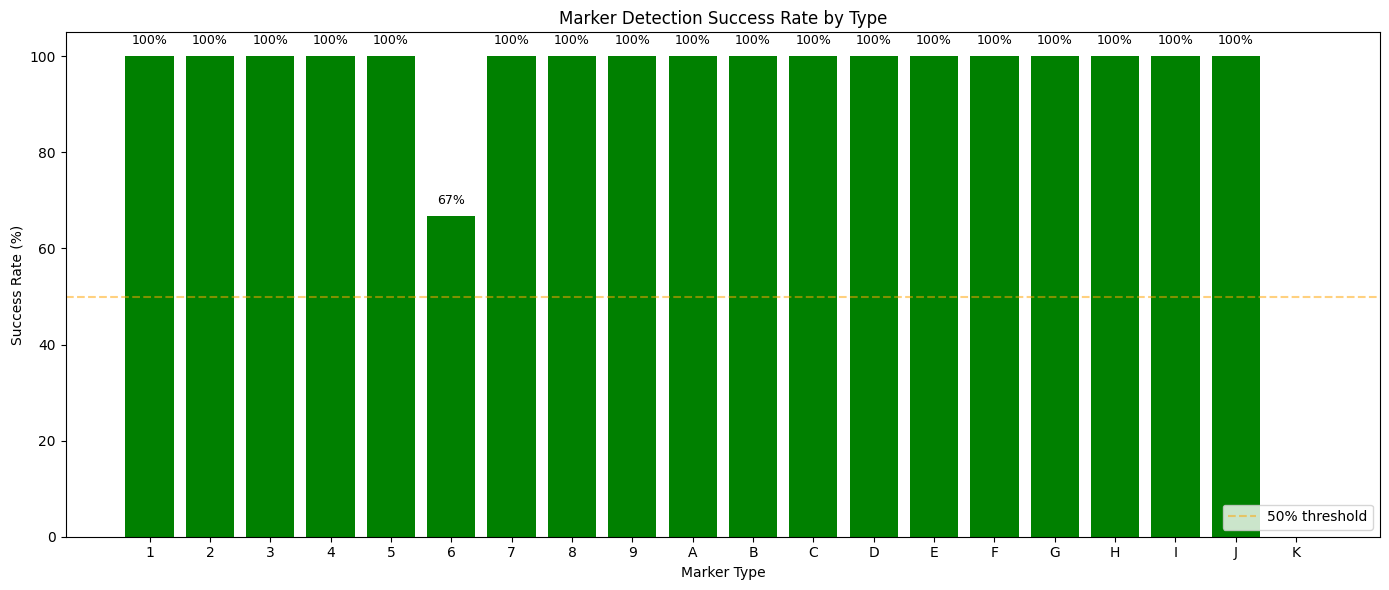

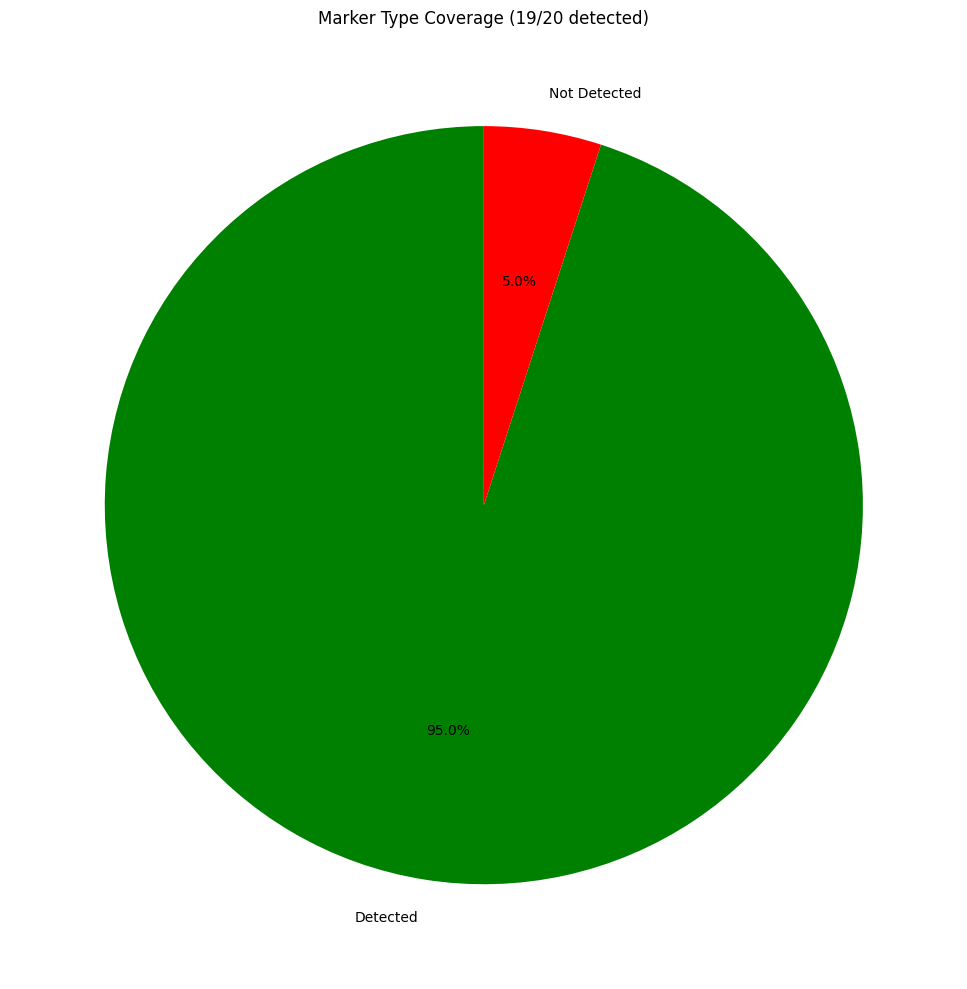

In [8]:
# Bar chart: Success rate by marker type
plt.figure(figsize=(14, 6))

markers = [row['marker'] for row in summary]
success_rates = [row['success_rate'] for row in summary]
colors = ['green' if sr > 0 else 'red' for sr in success_rates]

plt.bar(markers, success_rates, color=colors)
plt.xlabel('Marker Type')
plt.ylabel('Success Rate (%)')
plt.title('Marker Detection Success Rate by Type')
plt.ylim(0, 105)

# Add value labels on bars
for i, (marker, rate) in enumerate(zip(markers, success_rates)):
    if rate > 0:
        plt.text(i, rate + 2, f'{rate:.0f}%', ha='center', va='bottom', fontsize=9)

plt.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Pie chart: Marker coverage
plt.figure(figsize=(10, 10))

detected_count = sum(1 for row in summary if row['detected'] > 0)
not_detected_count = len(MARKER_TYPES) - detected_count

if not_detected_count > 0:
    plt.pie(
        [detected_count, not_detected_count],
        labels=['Detected', 'Not Detected'],
        colors=['green', 'red'],
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Marker Type Coverage ({detected_count}/{len(MARKER_TYPES)} detected)')
    plt.tight_layout()
    plt.show()
else:
    print("All marker types detected! No pie chart needed.")